In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics

In [2]:
df=pd.read_csv('cust_churn.csv')

In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['TotalCharges'].value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [9]:
df.TotalCharges.value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [10]:
df.TotalCharges.isnull().sum()

np.int64(0)

In [11]:
count=df['tenure'].value_counts().sum()

In [12]:
count

np.int64(7043)

In [13]:
df.Churn.value_counts()/len(df)*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [14]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
df.tenure.mean()

np.float64(32.37114865824223)

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
df.tenure.mean('Churn'=='Yes')

np.float64(32.37114865824223)

In [18]:
df.tenure.mean('Churn'=='No')

np.float64(32.37114865824223)

In [19]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [20]:
#"Customers with shorter tenure are significantly more likely to churn.
# Average tenure of churned customers (18 months) is less than half that of retained customers (38 months).

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [22]:
# Customers paying higher monthly charges are more likely to churn.

In [23]:
df.groupby('Churn')['Contract'].value_counts()/len(df)*100

Churn  Contract      
No     Month-to-month    31.520659
       Two year          23.384921
       One year          18.557433
Yes    Month-to-month    23.498509
       One year           2.356950
       Two year           0.681528
Name: count, dtype: float64

In [24]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [25]:
# Nearly ~43% of Month-to-month customers churn.
# Only ~11% of One-year customers churn.
# Only ~3% of Two-year customers churn.
# Encouraging customers to move from Month-to-month to annual plans.
# Offering discounts for longer contracts.

In [26]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [27]:
# Customers without Tech Support are almost 3 times more likely to churn than customers with Tech Support.

In [28]:
df.drop('customerID', axis=1, inplace=True)

In [29]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [30]:
df=pd.read_csv('cust_churn.csv')

In [31]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [32]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [33]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['gender'].value_counts()

gender
1    3555
0    3488
Name: count, dtype: int64

In [34]:

df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [36]:
df=pd.read_csv('cust_churn.csv')
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [37]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [38]:
df = pd.get_dummies(df, drop_first=True)
df.shape

(7043, 6560)

In [39]:
df.dtypes.value_counts()

bool       6551
int64         8
float64       1
Name: count, dtype: int64

In [40]:
df.columns[:20]

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'Churn',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service'],
      dtype='object')

In [41]:
df=pd.read_csv('cust_churn.csv')
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [42]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [43]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [44]:
df['TotalCharges'].dtype

dtype('float64')

In [45]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [46]:
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

C:\Users\visha\AppData\Local\Temp\ipykernel_21008\1854230864.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [47]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [48]:
df = pd.get_dummies(df, drop_first=True)

In [49]:
df.shape

(7043, 31)

In [50]:
from sklearn.model_selection import train_test_split

x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [52]:
x_train[:5]

array([[-1.02516569e+00, -4.37749204e-01, -9.69578591e-01,
         1.53218588e+00, -4.65683364e-01,  3.29573443e-01,
        -1.20000722e+00, -4.73723375e-04, -4.22098852e-01,
        -3.29573443e-01, -8.60523366e-01, -8.87056733e-01,
        -5.24080751e-01, -5.24080751e-01,  1.58094240e+00,
        -5.24080751e-01, -7.33828011e-01, -5.24080751e-01,
         1.38479574e+00, -5.24080751e-01, -6.37762944e-01,
        -5.24080751e-01, -7.94748183e-01, -5.24080751e-01,
         1.25076217e+00,  1.91010860e+00, -5.58352808e-01,
        -5.27655848e-01, -7.09649831e-01,  1.84247002e+00],
       [-1.02516569e+00, -4.37749204e-01, -9.69578591e-01,
        -6.52662324e-01,  8.85536787e-01,  3.29573443e-01,
         8.33328321e-01,  1.07475386e+00,  1.25536630e+00,
        -3.29573443e-01,  1.16208349e+00,  1.12732361e+00,
        -5.24080751e-01, -5.24080751e-01, -6.32534113e-01,
        -5.24080751e-01,  1.36271713e+00, -5.24080751e-01,
        -7.22128160e-01, -5.24080751e-01, -6.37762944e-

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [54]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8204400283889283

In [55]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[934, 102],
       [151, 222]])

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [57]:
df=pd.read_csv('cust_churn.csv')
df.drop('customerID', axis=1, inplace=True)

In [58]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


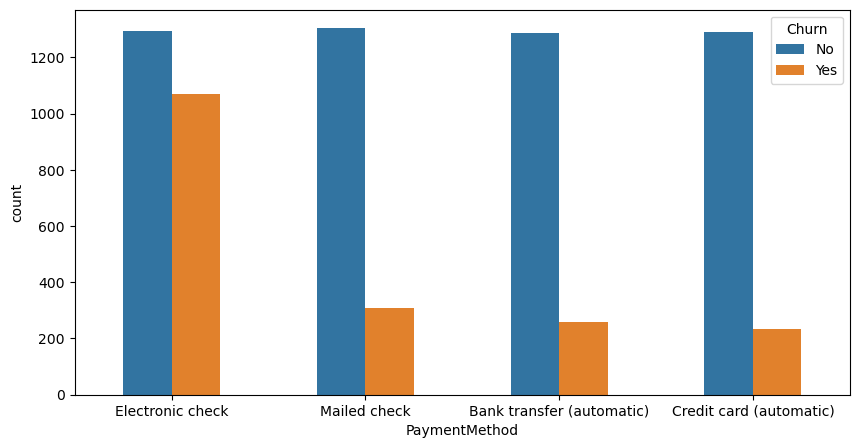

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn',width=0.5)
plt.show()

In [104]:
plt.savefig("contract_vs_churn.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [60]:
# Electronic check users churn at nearly 3× the rate of customers using automatic payments.

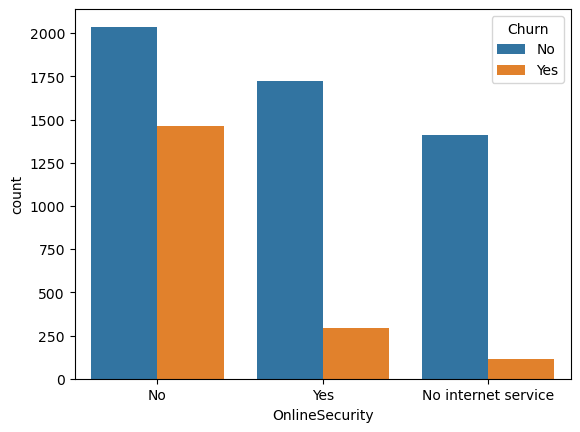

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.show()

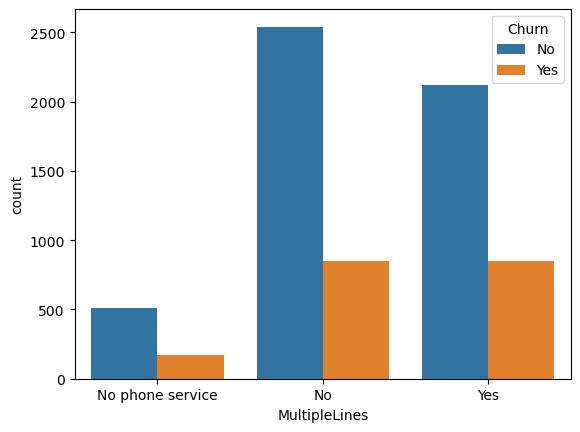

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='MultipleLines', hue='Churn')
plt.show()

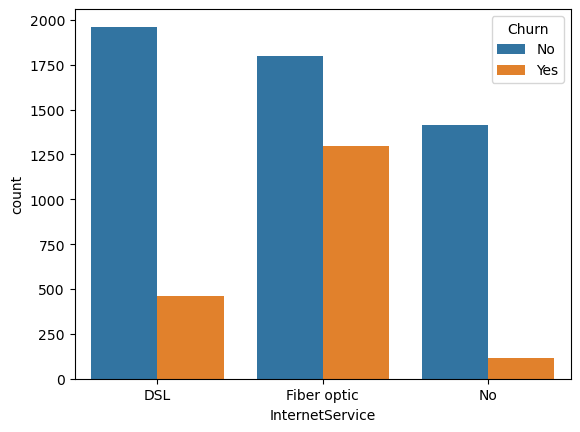

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.show()

In [64]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [65]:
#Fiber optic customers churn more than twice as much as DSL customers.

In [66]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


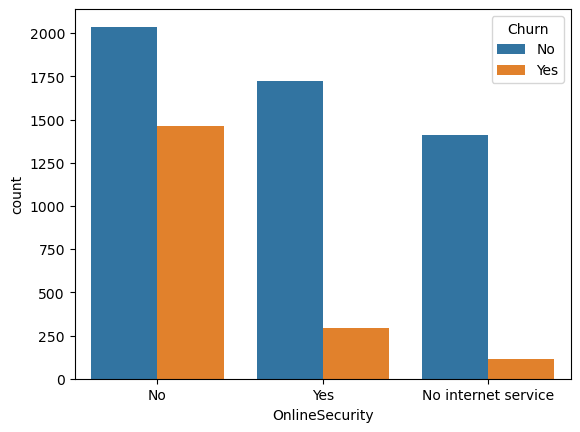

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.show()

In [68]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [69]:
# Customers without Online Security are almost 3 times more likely to churn than customers who have it.

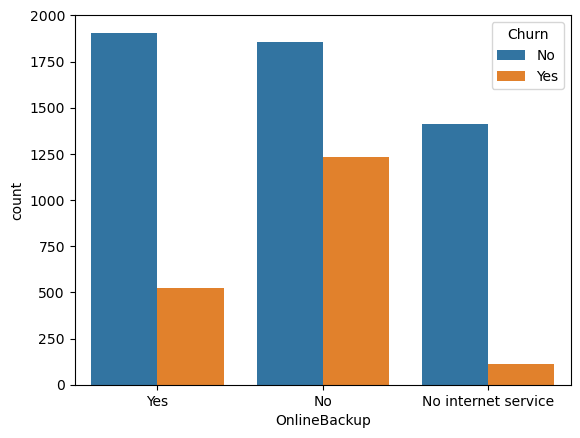

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='OnlineBackup', hue='Churn')
plt.show()

In [71]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [72]:
# Customers without Online Backup are almost twice as likely to churn as customers who have Online Backup.

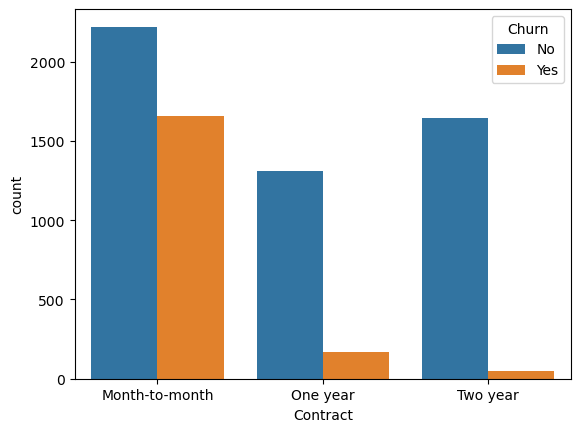

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()

In [74]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

In [75]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_dt)

0.709013484740951

In [76]:
dt.score(x_train, y_train)

0.9985800496982605

In [77]:
#Huge gap = Overfitting

In [78]:
DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
y_pred_dt = dt.predict(x_test)
accuracy_score(y_test, y_pred_dt)

0.709013484740951

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(x_train, y_train)

train_acc = dt.score(x_train, y_train)
test_acc = dt.score(x_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.7969471068512602
Test Accuracy: 0.8062455642299503


In [81]:
confusion_matrix(y_test, y_pred)

array([[934, 102],
       [151, 222]])

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [83]:
from sklearn.metrics import classification_report

y_pred_dt = dt.predict(x_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [84]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [85]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_rf)

0.7920511000709723

In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [87]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)


,Feature,Coefficient
11,InternetService_Fiber optic,0.624724
8,TotalCharges,0.609057
24,StreamingMovies_Yes,0.231376
22,StreamingTV_Yes,0.180866
10,MultipleLines_Yes,0.169119
6,PaperlessBilling,0.163500
28,PaymentMethod_Electronic check,0.151335
1,SeniorCitizen,0.058275
9,MultipleLines_No phone service,0.034217
18,DeviceProtection_Yes,0.028961


In [88]:
coefficients.sort_values(by='Coefficient').head(10)

,Feature,Coefficient
4,tenure,-1.310326
7,MonthlyCharges,-0.628853
26,Contract_Two year,-0.619081
25,Contract_One year,-0.269119
14,OnlineSecurity_Yes,-0.157574
20,TechSupport_Yes,-0.119683
17,DeviceProtection_No internet service,-0.075647
13,OnlineSecurity_No internet service,-0.075647
12,InternetService_No,-0.075647
19,TechSupport_No internet service,-0.075647


In [89]:
df.duplicated().sum()

np.int64(22)

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.duplicated().sum()

np.int64(0)

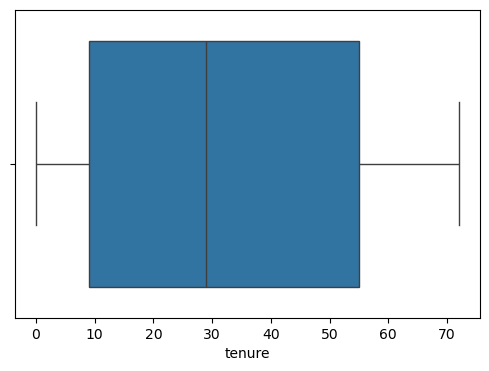

In [92]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['tenure'])
plt.show()

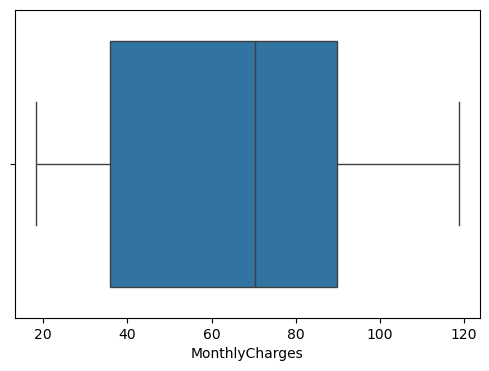

In [93]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

In [94]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [95]:
df.shape

(7021, 20)

In [96]:
import pandas as pd

df_clean = df.copy()

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].mean(), inplace=True)

df_clean.drop_duplicates(inplace=True)
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    if col == 'gender':
        df_clean[col] = df_clean[col].map({'Male':1,'Female':0})
    else:
        df_clean[col] = df_clean[col].map({'Yes':1,'No':0})

df_clean = pd.get_dummies(df_clean, drop_first=True)

df_clean.corr()['Churn'].sort_values(ascending=False)

C:\Users\visha\AppData\Local\Temp\ipykernel_21008\3449234755.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].mean(), inplace=True)


Churn                                    1.000000
InternetService_Fiber optic              0.308170
PaymentMethod_Electronic check           0.301544
MonthlyCharges                           0.194508
PaperlessBilling                         0.190891
SeniorCitizen                            0.151619
StreamingTV_Yes                          0.065032
StreamingMovies_Yes                      0.063192
MultipleLines_Yes                        0.041958
PhoneService                             0.011323
gender                                  -0.008763
MultipleLines_No phone service          -0.011323
DeviceProtection_Yes                    -0.064944
OnlineBackup_Yes                        -0.081092
PaymentMethod_Mailed check              -0.092562
PaymentMethod_Credit card (automatic)   -0.133666
Partner                                 -0.149135
Dependents                              -0.163459
TechSupport_Yes                         -0.163937
OnlineSecurity_Yes                      -0.170520


In [97]:
df=df_clean.copy()

In [98]:
df.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [99]:
corr_with_churn = df.corr()['Churn'].sort_values(ascending=False)
print(corr_with_churn)

Churn                                    1.000000
InternetService_Fiber optic              0.308170
PaymentMethod_Electronic check           0.301544
MonthlyCharges                           0.194508
PaperlessBilling                         0.190891
SeniorCitizen                            0.151619
StreamingTV_Yes                          0.065032
StreamingMovies_Yes                      0.063192
MultipleLines_Yes                        0.041958
PhoneService                             0.011323
gender                                  -0.008763
MultipleLines_No phone service          -0.011323
DeviceProtection_Yes                    -0.064944
OnlineBackup_Yes                        -0.081092
PaymentMethod_Mailed check              -0.092562
PaymentMethod_Credit card (automatic)   -0.133666
Partner                                 -0.149135
Dependents                              -0.163459
TechSupport_Yes                         -0.163937
OnlineSecurity_Yes                      -0.170520


In [100]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8619574668502283


In [101]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print(cv_scores)
print("Mean Accuracy:", cv_scores.mean())

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

[0.80269695 0.81121363 0.7920511  0.80965909 0.80539773]
Mean Accuracy: 0.8042036986257178


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


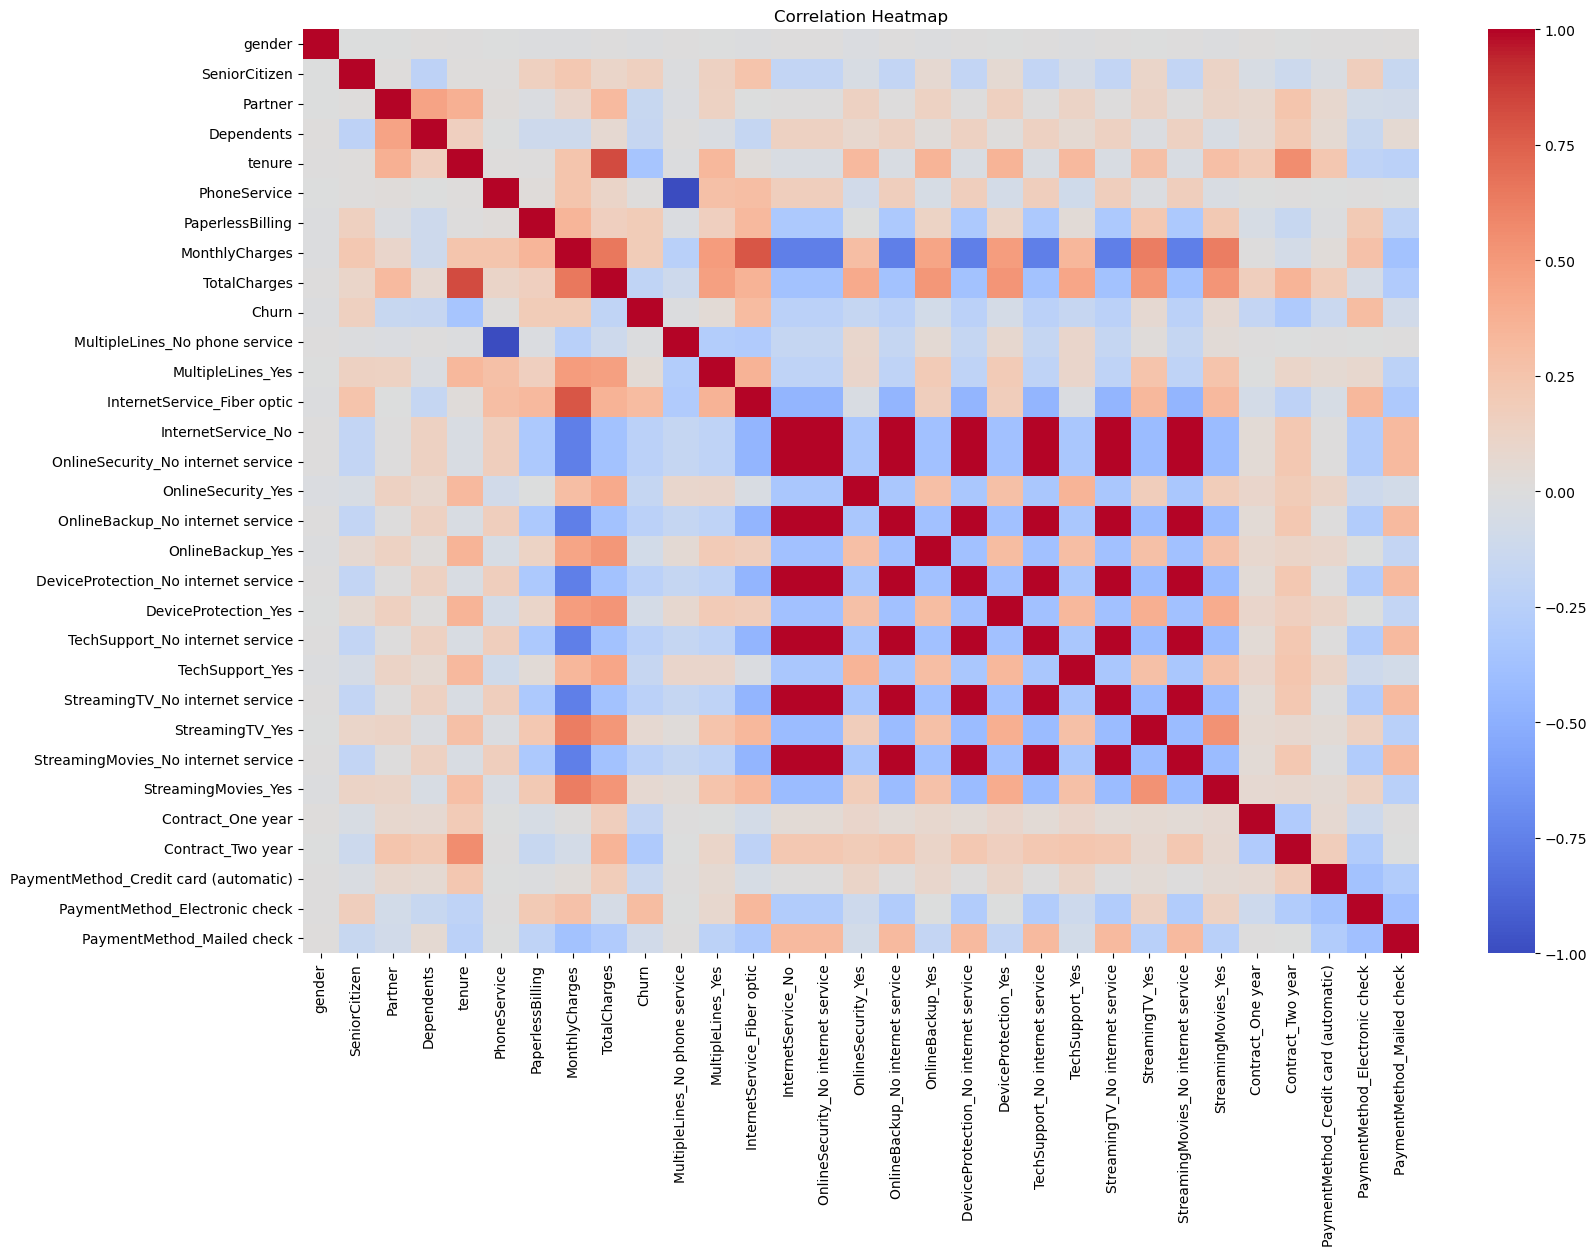

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [111]:
# The correlation heatmap revealed moderate-to-strong relationships among internet-related service features,
# indicating that customers often subscribe to multiple value-added services together.
#     The heatmap also helped identify features associated with churn and detect multicollinearity before model development.

In [112]:
import pandas
import numpy
import matplotlib
import seaborn
import sklearn

print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("sklearn:", sklearn.__version__)

pandas: 2.3.3
numpy: 2.3.5
matplotlib: 3.10.6
seaborn: 0.13.2
sklearn: 1.7.2
